# Pipeline

- BANDPASS -> CSP -> LDA

- Mean Accuracy: 53.5 %

# Load the Data

In [360]:
import numpy as np

data = np.load("Datasets/Main.npz")
X = data["X_csp"]
y = data["y"]

# Dropping Channels

In [361]:
# C3 -> 3
# Cz -> 4 
# C4 -> 5
BAD_CHANNELS = [0]
X = np.delete(X, BAD_CHANNELS, axis=1)
print(X.shape)

(180, 7, 750)


## Z Peaks Rejection

In [362]:
import numpy as np
from brainflow.data_filter import DataFilter

spike_thresh = 15
z_threshold = 4.0
lag = 50
influence = 0.0

good_trials = []
bad_trials = []

for i in range(X.shape[0]):
    trial_bad = False

    for ch in range(X.shape[1]):
        sig = X[i, ch]

        peaks = DataFilter.detect_peaks_z_score(
            sig,
            lag=lag,
            threshold=z_threshold,
            influence=influence
        )

        spike_count = np.sum(peaks != 0)

        if spike_count > spike_thresh:
            trial_bad = True
            break

    if trial_bad:
        bad_trials.append(i)
    else:
        good_trials.append(i)

good_trials = np.array(good_trials)
bad_trials = np.array(bad_trials)

X_clean = X[good_trials]
y_clean = y[good_trials]

print("Original X:", X.shape)
print("Clean X:", X_clean.shape)
print("Kept:", len(good_trials))
print("Rejected:", len(bad_trials))
print("Bad trial indices:", bad_trials)

X = X_clean
y = y_clean

Original X: (180, 7, 750)
Clean X: (154, 7, 750)
Kept: 154
Rejected: 26
Bad trial indices: [  1   4   8  14  16  36  38  40  47  62  65  66  76  77  83  98 110 125
 126 128 135 136 138 144 153 171]


# Preliminary Filtering

In [363]:
from brainflow.data_filter import (
    DataFilter,
    FilterTypes,
    DetrendOperations
)

FS = 250

for trial in range(X.shape[0]):
    for ch in range(X.shape[1]):

        DataFilter.detrend(
            X[trial, ch],
            DetrendOperations.CONSTANT.value
        )

        DataFilter.perform_bandpass(
            X[trial, ch],
            FS,
            8.0,
            13.0,
            4,
            FilterTypes.BUTTERWORTH_ZERO_PHASE.value,
            0
        )

## Plot Pre CSP

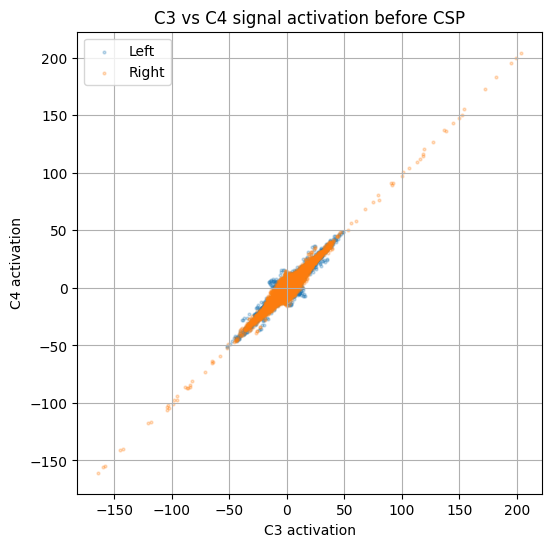

In [364]:
import numpy as np
import matplotlib.pyplot as plt

# X shape: (trials, channels, samples)
# y shape: (trials,) labels, e.g. 0 = left, 1 = right

C3_IDX = 0   
C4_IDX = 2   

LEFT = 1
RIGHT = 2

plt.figure(figsize=(6, 6))

for label, name in [(LEFT, "Left"), (RIGHT, "Right")]:
    X_class = X[y == label]  # shape: (class_trials, 3, 750)

    c3 = X_class[:, C3_IDX, :].reshape(-1)
    c4 = X_class[:, C4_IDX, :].reshape(-1)

    plt.scatter(c3, c4, s=4, alpha=0.25, label=name)

plt.xlabel("C3 activation")
plt.ylabel("C4 activation")
plt.title("C3 vs C4 signal activation before CSP")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# CSP Activation

In [365]:
import numpy as np
from brainflow.data_filter import DataFilter

LEFT = 1
RIGHT = 2

y_csp = np.zeros_like(y, dtype=np.float64)
y_csp[y == RIGHT] = 1.0

mask = (y == LEFT) | (y == RIGHT)

X_bf = np.ascontiguousarray(X[mask], dtype=np.float64)
y_bf = np.ascontiguousarray(y_csp[mask], dtype=np.float64)
filters, eigenvalues = DataFilter.get_csp(X_bf, y_bf)

X_csp_signal = np.array([
    filters @ trial
    for trial in X_bf
])

print("X_csp_signal:", X_csp_signal.shape)

X = X_csp_signal
y = y_bf

X_csp_signal: (154, 7, 750)


In [366]:
eigenvalues

array([0.41837493, 0.44622965, 0.45192271, 0.46662577, 0.49803097,
       0.50975099, 0.55614254])

# Post CSP Plot

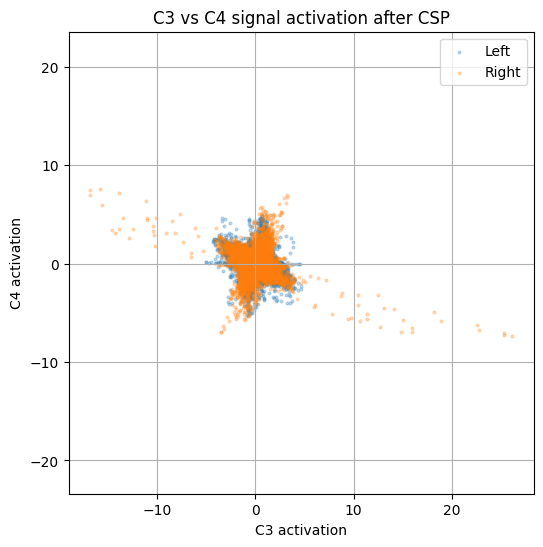

In [367]:
import numpy as np
import matplotlib.pyplot as plt

C3_IDX = 0   
C4_IDX = 2   

LEFT = 0
RIGHT = 1

plt.figure(figsize=(6, 6))

for label, name in [(LEFT, "Left"), (RIGHT, "Right")]:
    X_class = X[y == label]  # shape: (class_trials, 3, 750)

    c3 = X_class[:, C3_IDX, :].reshape(-1)
    c4 = X_class[:, C4_IDX, :].reshape(-1)

    plt.scatter(c3, c4, s=4, alpha=0.25, label=name)

plt.xlabel("C3 activation")
plt.ylabel("C4 activation")
plt.title("C3 vs C4 signal activation after CSP")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# LDA

In [368]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np

var = np.var(X, axis=2)
var = np.where(var == 0, 1e-12, var)
features = np.log(var)

lda = LinearDiscriminantAnalysis(
    solver="eigen",
    shrinkage="auto"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(lda, features, y, cv=cv)

print("CV scores:", scores)
print("Mean accuracy:", np.mean(scores))
print("Std accuracy :", np.std(scores))
print("Best fold    :", np.max(scores))
print("Worst fold   :", np.min(scores))

CV scores: [0.5483871  0.58064516 0.5483871  0.41935484 0.53333333]
Mean accuracy: 0.5260215053763441
Std accuracy : 0.05552553241241405
Best fold    : 0.5806451612903226
Worst fold   : 0.41935483870967744
